<a href="https://colab.research.google.com/github/Ataurcuet-hub/ML-Foundations-for-Research/blob/main/MLClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Start K-Means Clustering
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

In [ ]:
dataset=pd.read_csv('sample_data/data-income-age-group.csv')
dataset.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [ ]:
#Scaling needed for this dataset
Scaler= MinMaxScaler()
Scaler.fit(dataset[['Income($)']])
dataset['Income($)']= Scaler.transform(dataset[['Income($)']])
Scaler.fit(dataset[['Age']])
dataset['Age']= Scaler.transform(dataset[['Age']])
dataset.head()


,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


Text(0.5, 1.0, 'Visual Raw data')

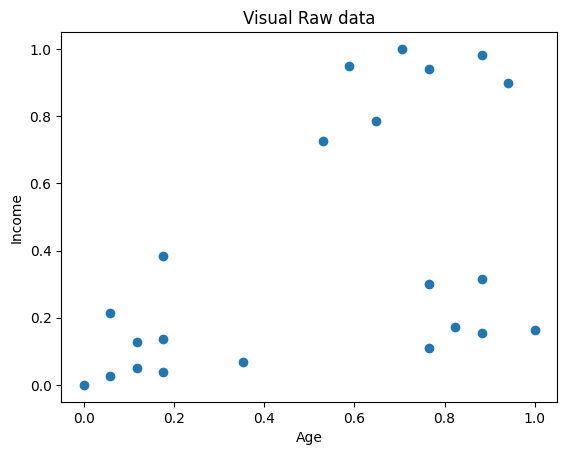

In [ ]:
from matplotlib.backend_bases import colors
#Visualize the Raw dataset
plt.scatter(dataset.Age,dataset['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Visual Raw data')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


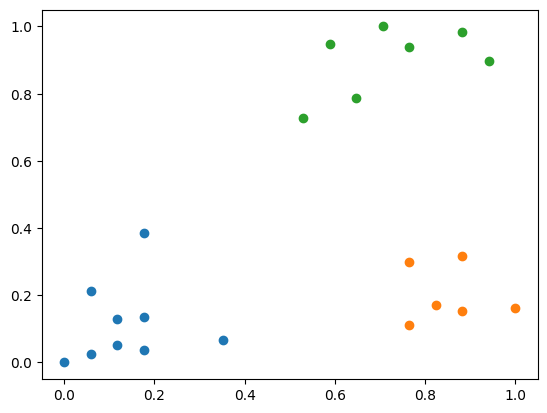

In [ ]:
#kMeans Clustering
from sklearn.cluster import KMeans
km= KMeans (n_clusters=3)
yPred=km.fit_predict(dataset[['Age', 'Income($)']])
#yPred=km.predict(dataset[['Age', 'Income($)']])
dataset['cluster']=yPred    #Creat new Coloumn of Cluster
#dataset.head()
#new chart for Clusterd datasets
dataset1= dataset[dataset.cluster==0]
dataset2= dataset[dataset.cluster==1]
dataset3= dataset[dataset.cluster==2]
#plot this clustered dataset
plt.scatter(dataset1.Age, dataset1['Income($)'])
plt.scatter(dataset2.Age, dataset2['Income($)'])
plt.scatter(dataset3.Age, dataset3['Income($)'])

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

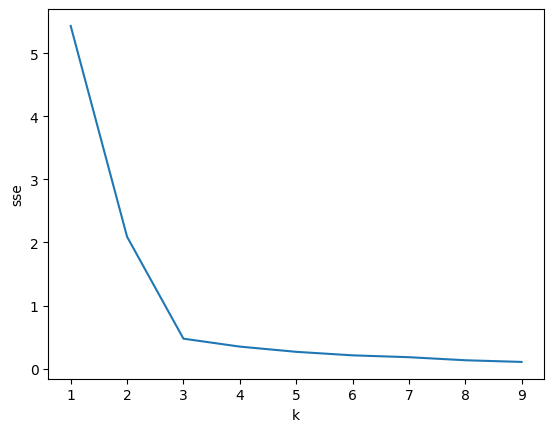

In [ ]:
#If cluster number unknown(Elbow Method)
sse=[]
KRange=range(1,10)
for k in KRange:
  km=KMeans (n_clusters=k)
  km.fit(dataset[['Age','Income($)']])
  sse.append(km.inertia_)
plt.xlabel('k')
plt.ylabel('sse')
plt.plot(KRange,sse)

In [ ]:
#Hierarchial Clustering
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [ ]:
plt.figure(figsize=(10,7))
x= dataset [['Age','Income($)']].values

<Figure size 1000x700 with 0 Axes>

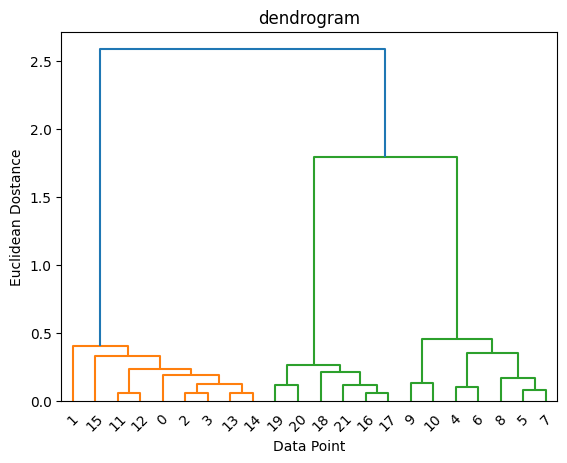

In [ ]:
#dendogram for calculate error in cluster
dendrogram=sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('dendrogram')
plt.xlabel('Data Point')
plt.ylabel('Euclidean Dostance')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


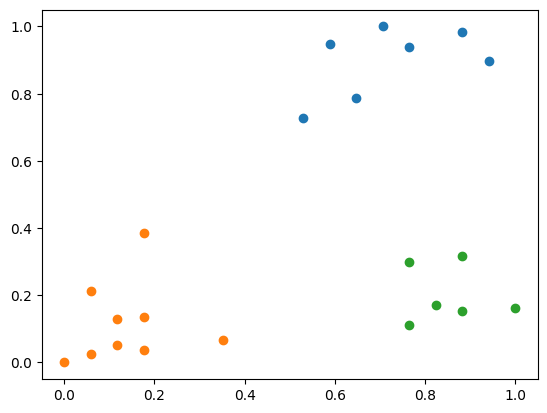

In [ ]:
#Now Clustering
cluster=AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
yPredAHC=cluster.fit_predict(x)

#to visualize clusters
dataset['cluster']=yPredAHC    #Creat new Coloumn of Cluster
dataset.head()
#new chart for Clusterd datasets
dataset1= dataset[dataset.cluster==0]
dataset2= dataset[dataset.cluster==1]
dataset3= dataset[dataset.cluster==2]
#plot this clustered dataset
plt.scatter(dataset1.Age, dataset1['Income($)'])
plt.scatter(dataset2.Age, dataset2['Income($)'])
plt.scatter(dataset3.Age, dataset3['Income($)'])



In [ ]:
#WHich clustring give better result

from sklearn.metrics import silhouette_score
silhouetteScoreAHC= silhouette_score (x,yPredAHC)
silhouetteScoreKMS= silhouette_score (dataset[['Age','Income($)']],yPred)
print("silhouette Prediction Score: " +str(silhouetteScoreAHC))
print("silhouette Prediction Score: " +str(silhouetteScoreKMS))

silhouette Prediction Score: 0.7129710183539275
silhouette Prediction Score: 0.7129710183539275
